# **Spending, Income and LAYS Analysis**

This notebook examines how GDP per capita and public financing patterns are associated with Learning-Adjusted Years of Schooling (LAYS) across countries.
It uses harmonized country-level inputs from prepared analysis files and compares multiple model specifications, including nonlinear and subgroup models.
Final communication outputs are exported to `Results/figures/` and `Results/tables/`.

# **Load Packages**

In [3]:
#========================================
# Import required packages
#========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Ellipse
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path
import json
import sys
sys.path.append(r"C:\Users\F.Turner\Documents\00. Analyses")
import use_funcs
from use_funcs import find_project_root

# **Create Helper Functions**

Define plotting palette and project path helpers used throughout the notebook.

In [4]:
#========================================
# Define Save the Children colour palette
#========================================

sc_colors = {'red': '#da291c',
             'medium red' : '#ed7b73',
             'light red': '#f9d3d0',
             'purple': '#ae90c3',
             'medium purple': '#cebcdb',
             'light purple': '#efe9f3',
             'yellow': '#fecf28',
             'medium yellow': '#ffeca9',
             'light yellow': '#fff5d4',
             'blue': '#99cccc',
             'medium blue' : '#d6ebeb',
             'light blue' : '#ebf5f5',
             'green' : '#45b283',
             'medium green' : '#8dd3b5',
             'light green' : '#d9f0e6',
             'grey' : '#e7e6e6'}

mpl.rcParams['font.family'] = 'Calibri' 

In [5]:
#========================================
# Configure project paths and output folders
#========================================

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "path_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    PATHS = json.load(f)

IMP_DIR = (PROJECT_ROOT / PATHS["imports_dir"]).resolve()
HO_DIR = (PROJECT_ROOT / PATHS["handoff_dir"]).resolve()
EXP_DIR = (PROJECT_ROOT / PATHS["exports_dir"]).resolve()
FIG_DIR = (PROJECT_ROOT / PATHS["figures_dir"]).resolve()
TAB_DIR = (PROJECT_ROOT / PATHS["tables_dir"]).resolve()

for folder in [IMP_DIR, HO_DIR, EXP_DIR, FIG_DIR, TAB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMP_DIR:", IMP_DIR)
print("HO_DIR:", HO_DIR)
print("EXP_DIR:", EXP_DIR)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

PROJECT_ROOT: C:\Users\F.Turner\Documents\00. Analyses\Education Financing
IMP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Data
HO_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Handoff
EXP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results
FIG_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\figures
TAB_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\tables


# **Load Data**

Load the prepared merged datasets used in the modeling and visualization steps.

In [6]:
#========================================
# Load core analysis datasets
#========================================

all_data = pd.read_csv(IMP_DIR / "all_data.csv")
lays_panels = pd.read_csv(IMP_DIR / "lays_panels.csv")

# **Analysis**

The following cells estimate the relationship between GDP per capita and LAYS, test alternative curve shapes, and assess differences by income group.

# **Does GDPPC Correlate with LAYS?**

In [7]:
all_data['expenditure_perchild_ppp'].describe()
all_data = all_data.drop(all_data[all_data['expenditure_perchild_ppp'] < 10].index, axis=0)

In [8]:
#========================================
# Build country-level base dataset for GDPPC-LAYS models
#========================================

df = all_data.copy()
df = df.dropna(subset=["lays", "gdppc_2015_usd"])
df = df.drop(df[df['income_group'] == 'Not classified'].index, axis=0)
df = df[["iso3",
         "year",
         "income_group",
         "lays",
         "gdppc_2015_usd",
         'expenditure_perchild_ppp',
         'expenditure_pctbudget_uis',
        'expenditure_pctgdp'
         ]]

df = df.groupby(["iso3"]).agg('first').reset_index()

# What is the relationship between GDPPC and LAYS?

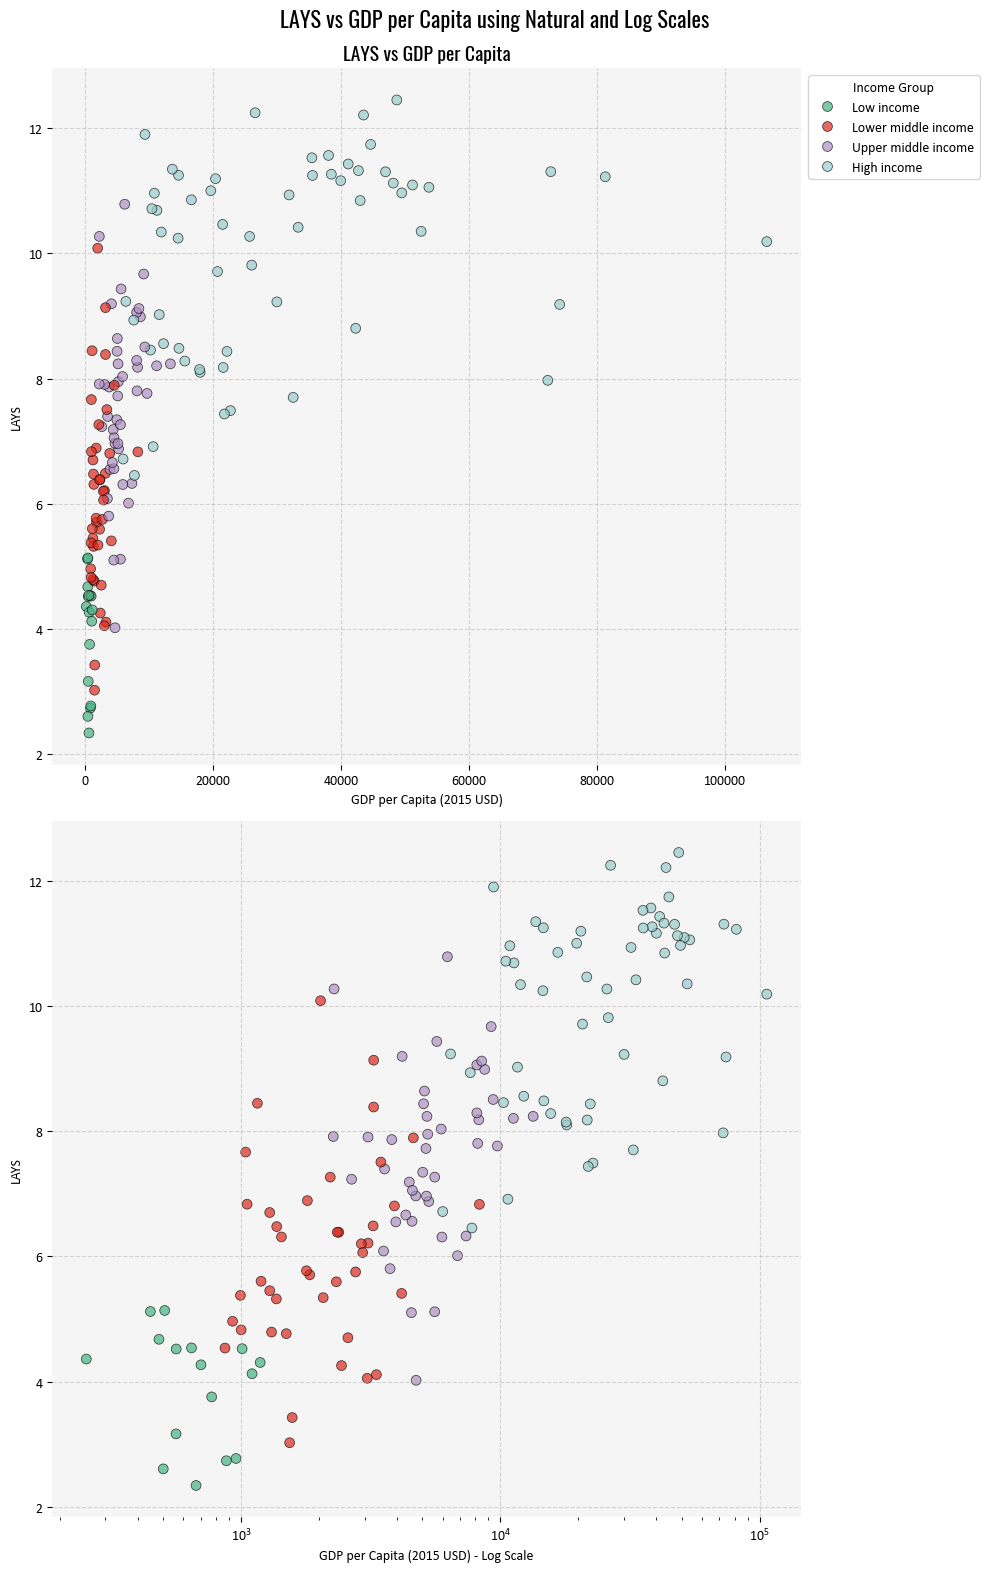

In [32]:
#========================================
# Plot LAYS against GDPPC in level and log scale
#========================================

fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax = ax.flatten()

sns.scatterplot(
    data=df,
    x="gdppc_2015_usd",
    y="lays",
    hue="income_group",
    palette={
        "Low income": sc_colors["green"],
        "Lower middle income": sc_colors["red"],
        "Upper middle income": sc_colors["purple"],
        "High income": sc_colors["blue"],
    },
    edgecolor="black",
    alpha=0.7,
    s=50,
    ax=ax[0],
)

ax[0].set_title("LAYS vs GDP per Capita", fontsize=14, fontname='Oswald')
ax[0].set_xlabel("GDP per Capita (2015 USD)")
ax[0].set_ylabel("LAYS")
ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))


sns.scatterplot(data=df, x="gdppc_2015_usd", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[1])

ax[1].set_xscale("log")
ax[1].set_xlabel("GDP per Capita (2015 USD) - Log Scale")
ax[1].set_ylabel("LAYS")
ax[1].legend().set_visible(False)


for ax in ax.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('whitesmoke')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

fig.suptitle("LAYS vs GDP per Capita using Natural and Log Scales", fontsize=16, fontname='Oswald')

plt.tight_layout(rect=[0, 0, 1, 0.99])

fig.savefig(FIG_DIR / "lays_vs_gdppc_level_and_log.png", dpi=300, bbox_inches="tight")

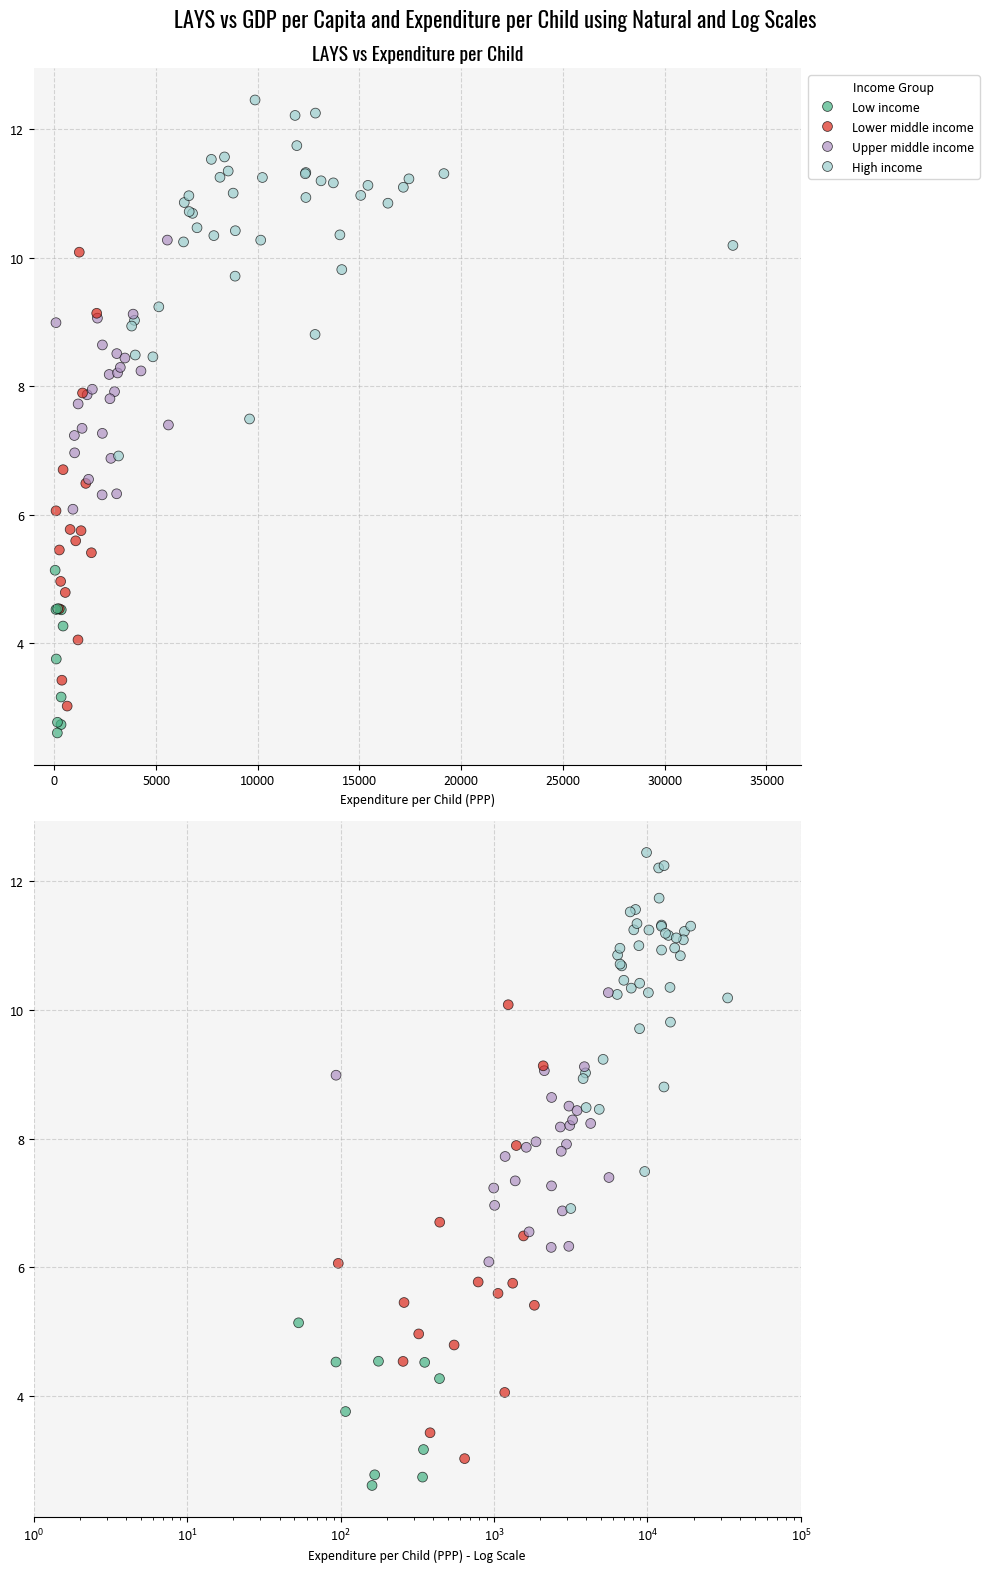

In [31]:
#========================================
# Plot LAYS against GDPPC in level and log scale
#========================================

fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax = ax.flatten()

sns.scatterplot(data=df, x="expenditure_perchild_ppp", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[0])

ax[0].set_title("LAYS vs Expenditure per Child", fontsize=14, fontname='Oswald')
ax[0].set_xlabel("Expenditure per Child (PPP)")
ax[0].set_ylabel("")
ax[0].set_xlim(-1000, df["expenditure_perchild_ppp"].max() * 1.1)
ax[0].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))


sns.scatterplot(data=df, x="expenditure_perchild_ppp", 
                y="lays", 
                hue="income_group",  
                palette = {"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue']},
                edgecolor='black',
                 alpha=0.7,
                 s=50,
                ax=ax[1])

ax[1].set_xlabel("Expenditure per Child (PPP) - Log Scale")
ax[1].set_xlim(1, 100000)
ax[1].set_ylabel("")
ax[1].set_xscale("log")
ax[1].legend().set_visible(False)


for ax in ax.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_facecolor('whitesmoke')
    ax.spines[['top', 'right', 'left']].set_visible(False)

fig.suptitle("LAYS vs GDP per Capita and Expenditure per Child using Natural and Log Scales", fontsize=16, fontname='Oswald')

plt.tight_layout(rect=[0, 0, 1, 0.99])

fig.savefig(FIG_DIR / "lays_vs_gdppc_level_and_log.png", dpi=300, bbox_inches="tight")

In [106]:
#============================================================================
# Estimate linear, log, and quartic GDPPC models for GDPPC-LAYS relationship
#============================================================================

df1 = df.copy()

y = df1["lays"]

df1 = df1.rename(columns={"gdppc_2015_usd": "gdppc"})
df1['gdppc_s'] = (df1['gdppc'] - df1['gdppc'].mean()) / df1['gdppc'].std()

# Model 1. Linear Regression

X = df1[["gdppc_s"]]
X = sm.add_constant(X)
model_linear = sm.OLS(y, X).fit()

print("Model 1 - Linear Regression Summary:")
print(model_linear.summary())

# Model 2. Log-GDPPC Regression

df1['log_gdppc'] = np.log(df1['gdppc'])

X = df1[["log_gdppc"]]
X = sm.add_constant(X)
model_log = sm.OLS(y, X).fit()
print("\n\nModel 2 - Log-GDPPC Regression Summary:")
print(model_log.summary())

# 3. Quartic Regression 

df1['gdppc2'] = df1['gdppc_s'] ** 2
df1['gdppc3'] = df1['gdppc_s'] ** 3
df1['gdppc4'] = df1['gdppc_s'] ** 4

X = df1[["gdppc_s", "gdppc2", "gdppc3", "gdppc4"]]

X = sm.add_constant(X)

model_quartic = sm.OLS(y, X).fit()

print("\n\nModel 3 - Quartic Regression Summary:")
print(model_quartic.summary())

Model 1 - Linear Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     107.4
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.49e-19
Time:                        16:47:46   Log-Likelihood:                -332.65
No. Observations:                 161   AIC:                             669.3
Df Residuals:                     159   BIC:                             675.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [107]:
#========================================
# Estimate linear, log, and quartic GDPPC models
#========================================

df2 = df.copy()
df2 = df2.dropna(subset=["expenditure_perchild_ppp"])

y = df2["lays"]

df2 = df2.rename(columns={"expenditure_perchild_ppp": "pcppp"})
df2['pcppp_s'] = (df2['pcppp'] - df2['pcppp'].mean()) / df2['pcppp'].std()

# Model 1. Linear Regression

X = df2[["pcppp_s"]]
X = sm.add_constant(X)
model_linear2 = sm.OLS(y, X).fit()

print("Model 1 - Linear Regression Summary:")
print(model_linear2.summary())

# Model 2. Log-GDPPC Regression

df2['log_pcppp'] = np.log(df2['pcppp'])

X = df2[["log_pcppp"]]
X = sm.add_constant(X)
model_log2 = sm.OLS(y, X).fit()
print("\n\nModel 2 - Log-GDPPC Regression Summary:")
print(model_log2.summary())

# 3. Quartic Regression 

df2['pcppp2'] = df2['pcppp_s'] ** 2
df2['pcppp3'] = df2['pcppp_s'] ** 3
df2['pcppp4'] = df2['pcppp_s'] ** 4

X = df2[["pcppp_s", "pcppp2", "pcppp3", "pcppp4"]]

X = sm.add_constant(X)

model_quartic2 = sm.OLS(y, X).fit()

print("\n\nModel 3 - Quartic Regression Summary:")
print(model_quartic2.summary())

Model 1 - Linear Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     101.5
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.43e-16
Time:                        16:47:49   Log-Likelihood:                -192.20
No. Observations:                  95   AIC:                             388.4
Df Residuals:                      93   BIC:                             393.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

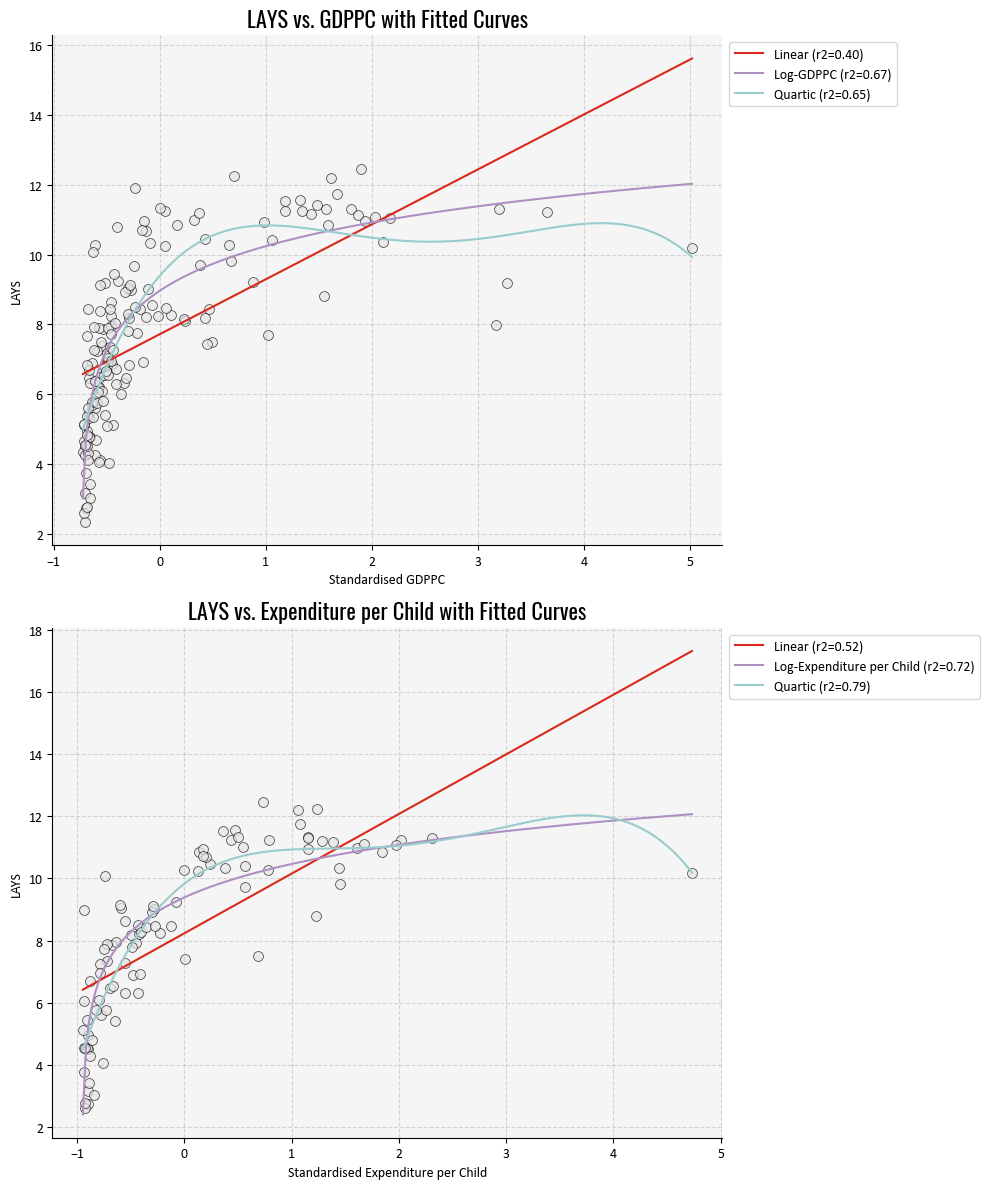

In [108]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12))
ax = ax.flatten()


#============================================================================
# Compare fitted linear, log, and quartic curves for GDPPC-LAYS relationship
#=============================================================================

# Create x grid
x_pred_s = np.linspace(df1["gdppc_s"].min(), df1["gdppc_s"].max(), 200)
x_pred_gdppc = x_pred_s * df1["gdppc"].std() + df1["gdppc"].mean()
x_pred_log = np.log(x_pred_gdppc)

X_pred_linear = sm.add_constant(pd.DataFrame({"gdppc_s": x_pred_s}), 
                                has_constant="add")
X_pred_log = sm.add_constant(pd.DataFrame({"log_gdppc": x_pred_log}), 
                             has_constant="add")
X_pred_quartic = pd.DataFrame({
    "gdppc_s": x_pred_s,
    "gdppc2": x_pred_s ** 2,
    "gdppc3": x_pred_s ** 3,
    "gdppc4": x_pred_s ** 4,
})
X_pred_quartic = sm.add_constant(X_pred_quartic, has_constant="add")

y_linear = model_linear.predict(X_pred_linear)
y_log = model_log.predict(X_pred_log)
y_quartic = model_quartic.predict(X_pred_quartic)


ax[0].plot(x_pred_s, y_linear, 
        label=f"Linear (r2={model_linear.rsquared:.2f})", 
        color=sc_colors['red'])
ax[0].plot(x_pred_s, y_log, 
        label=f"Log-GDPPC (r2={model_log.rsquared:.2f})", 
        color=sc_colors['purple'])
ax[0].plot(x_pred_s, y_quartic, 
        label=f"Quartic (r2={model_quartic.rsquared:.2f})", 
        color=sc_colors['blue'])

sns.scatterplot(data=df1, x="gdppc_s", y="lays", ax=ax[0], 
                color=sc_colors['grey'], edgecolor='black', alpha=0.7, s=50)

ax[0].set_title("LAYS vs. GDPPC with Fitted Curves", fontname='Oswald', fontsize=16)

ax[0].set_xlabel("Standardised GDPPC")
ax[0].set_ylabel("LAYS")

ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_facecolor('whitesmoke')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].spines[['top', 'right']].set_visible(False)

#===================================================================
# Compare fitted linear, log, and quartic curves for Expenditure per Child
#===================================================================

# Create x grid
x_pred_s = np.linspace(df2["pcppp_s"].min(), df2["pcppp_s"].max(), 200)
x_pred_pcppp = x_pred_s * df2["pcppp"].std() + df2["pcppp"].mean()
x_pred_log = np.log(x_pred_pcppp)

X_pred_linear = sm.add_constant(pd.DataFrame({"pcppp_s": x_pred_s}), 
                                has_constant="add")
X_pred_log = sm.add_constant(pd.DataFrame({"log_pcppp": x_pred_log}), 
                             has_constant="add")
X_pred_quartic = pd.DataFrame({
    "pcppp_s": x_pred_s,
    "pcppp2": x_pred_s ** 2,
    "pcppp3": x_pred_s ** 3,
    "pcppp4": x_pred_s ** 4,
})
X_pred_quartic = sm.add_constant(X_pred_quartic, has_constant="add")

y_linear = model_linear2.predict(X_pred_linear)
y_log = model_log2.predict(X_pred_log)
y_quartic = model_quartic2.predict(X_pred_quartic)

ax[1].plot(x_pred_s, y_linear, 
        label=f"Linear (r2={model_linear2.rsquared:.2f})", 
        color=sc_colors['red'])
ax[1].plot(x_pred_s, y_log, 
        label=f"Log-Expenditure per Child (r2={model_log2.rsquared:.2f})", 
        color=sc_colors['purple'])
ax[1].plot(x_pred_s, y_quartic, 
        label=f"Quartic (r2={model_quartic2.rsquared:.2f})", 
        color=sc_colors['blue'])

sns.scatterplot(data=df2, x="pcppp_s", y="lays", ax=ax[1], 
                color=sc_colors['grey'], edgecolor='black', alpha=0.7, s=50)

ax[1].set_title("LAYS vs. Expenditure per Child with Fitted Curves", fontname='Oswald', fontsize=16)

ax[1].set_xlabel("Standardised Expenditure per Child")
ax[1].set_ylabel("LAYS")

ax[1].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[1].set_facecolor('whitesmoke')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# Save Figures

fig.savefig(FIG_DIR / "fitted_curves_gdppc_lays.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fitted_curves_expenditureperchild_lays.png", dpi=300, bbox_inches="tight")

FIG 2: Fitting Curves for the relationship between GDP Per Capita (GDPPC) and LAYS

Here we fit three different curves to plot the relationship between GDPPC and LAYS. The first is a line, which is a relatively poor fit, explaining 43 percent of the variance in our standardised measure of GDPPC (standardised to allow for fitting of our quartic regression curve). Second, we plot the relationship between log-GDPPC and LAYS, which shows an initial steep relationship between GDPPC and LAYS, which becomes shallower for richer countries. Finally, mirroring Pritchett et al. (2026) we fit a quartic curve with linear, quadratic, cubic and quartic coefficients. This explains slightly less variance than our log model, but shows a steep initial rise, before a slight dip, a slight rise, and a final dip for the richest countries. 

Overall, our log model explains the most variance, and aligns with our theoretical expectation of diminishing returns on spending. Our next question is whether this relationship is consistent across income groups. 

## Do Slopes Vary by Income Group

In [14]:
#========================================
# Estimate interaction model across income groups
#========================================



df2 = df.copy()
df2 = df2.rename(columns={"gdppc_2015_usd": "gdppc", 'expenditure_perchild_ppp': "pcppp"})
df2['log_gdppc'] = np.log(df2['gdppc'])
df2['log_pcppp'] = np.log(df2['pcppp'])


# Create income group dummies
dummies = pd.get_dummies(df2["income_group"], prefix="inc", drop_first=True)
df2 = pd.concat([df2, dummies], axis=1)

# MODEL 4 - Log-GDPPC with Income Group Dummies and Interactions

df4 = df2.dropna(subset=["log_gdppc"]).copy()

y = df4["lays"]


# Create interaction terms
for col in dummies.columns:
    df4[f"log_gdppc_{col}"] = df4["log_gdppc"] * df4[col]

# Now build X
X_vars = ["log_gdppc"] + [f"log_gdppc_{col}" for col in dummies.columns]

X = df4[X_vars]
X = X.astype(float)  # Ensure all data is numeric
X = sm.add_constant(X)

model4 = sm.OLS(y, X).fit()
print("\n\nModel 4 - Log-GDPPC with Income Group Dummies and Interactions Summary:")
print(model4.summary())

# MODEL 5 - Log-PCPPP with Income Group Dummies and Interactions

df5 = df2.dropna(subset=["log_pcppp"]).copy()

y = df5["lays"]

# Create interaction terms
for col in dummies.columns:
    df5[f"log_pcppp_{col}"] = df5["log_pcppp"] * df5[col]

# Now build X
X_vars = ["log_pcppp"] + [f"log_pcppp_{col}" for col in dummies.columns]

X = df5[X_vars]
X = X.astype(float)  # Ensure all data is numeric
X = sm.add_constant(X)

model5 = sm.OLS(y, X).fit()
print("\n\nModel 5 - Log-PCPPP with Income Group Dummies and Interactions Summary:")
print(model5.summary())




Model 4 - Log-GDPPC with Income Group Dummies and Interactions Summary:
                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     92.54
Date:                Fri, 22 May 2026   Prob (F-statistic):           3.65e-40
Time:                        10:42:11   Log-Likelihood:                -276.32
No. Observations:                 161   AIC:                             562.6
Df Residuals:                     156   BIC:                             578.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

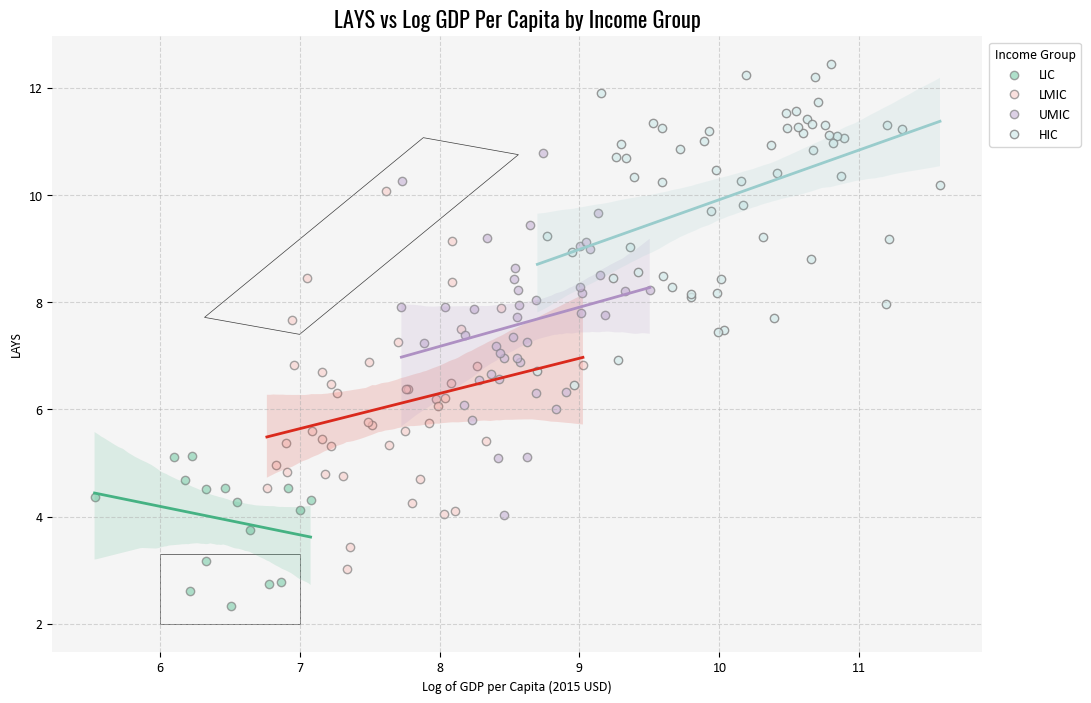

In [20]:
#========================================
# Fit and plot separate log-GDPPC slopes by income group
#========================================

## MODEL 5: Models per Income Group

df_lic = df2[df2['income_group'] == 'Low income']
df_lmic = df2[df2['income_group'] == 'Lower middle income']
df_umic = df2[df2['income_group'] == 'Upper middle income']
df_hic = df2[df2['income_group'] == 'High income']

fig, ax = plt.subplots(figsize=(12, 8))


sns.regplot(data=df_lic, 
            x="log_gdppc", 
            y="lays", 
            label="LIC", 
            scatter_kws={"color": sc_colors["medium green"], 
                         "edgecolor": 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["green"], "lw": 2},
            ax=ax)
sns.regplot(data=df_lmic, 
            x="log_gdppc", 
            y="lays", ax=ax, 
            label="LMIC",
            scatter_kws={"color": sc_colors["light red"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["red"], "lw": 2})
sns.regplot(data=df_umic, 
            x="log_gdppc", 
            y="lays", ax=ax, 
            label="UMIC", 
            scatter_kws={"color": sc_colors["medium purple"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["purple"], "lw": 2})
sns.regplot(data=df_hic, 
            x="log_gdppc", 
            y="lays", ax=ax, 
            label="HIC", 
            scatter_kws={"color": sc_colors["medium blue"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.8}, 
            line_kws={"color": sc_colors["blue"], "lw": 2})

# Highlight visually notable clusters
ax.add_patch(Rectangle((6, 2), 1.0, 1.3, angle=0,
                     facecolor='whitesmoke', 
                     edgecolor='black', 
                     alpha=0.75, lw=.5, zorder=0))

ax.add_patch(Rectangle((7, 7.4), 3.7, .75, angle=65,
                     facecolor='whitesmoke', 
                     edgecolor='black', 
                     alpha=0.75, lw=.5, zorder=0))

ax.legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))
ax.set_xlabel("Log of GDP per Capita (2015 USD)")
ax.set_ylabel("LAYS")
ax.set_title("LAYS vs Log GDP Per Capita by Income Group", 
             fontsize=16, 
             fontname='Oswald')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.set_facecolor('whitesmoke')
ax.grid(True, linestyle='--', alpha=0.5)



fig.savefig(FIG_DIR / "lays_vs_log_pcppp_by_income_group.png", 
            dpi=300, 
            bbox_inches="tight")

Fig 3: LAYS vs Log-GDPPC by Income Group

This figure shows the relationship between Log GDP Per Capita and LAYS per income group. While the overall relationship between log GDPPC and LAYS is strong and positive, when we disect it we see that for Low-Income Countries the relationship is negative, and not statistical distinguishable from zero. 

The implication of this is that, up to a certain threshold, increasing the amount of money in a system does not directly lead to improved institutions. 

What is also notable, is that for LMICs and UMICs we have a number positive outliers, i.e., countries achieving stronger LAYS than would be expected for their income level. Conversely, for LICs there seem to be a clustr of countries achieving less than their income level would predict. We haven't validated this statistically, but it is visually apparent in the figure. 

In [ ]:
#==============================================================
# Fit and plot separate log-Expenditure per Child slopes by income group
#==============================================================

sns.regplot(data=df_lic, 
            x="log_pcppp", 
            y="lays", 
            label="LIC", 
            scatter_kws={"color": sc_colors["medium green"], 
                         "edgecolor": 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["green"], "lw": 2},
            ax=ax[1])
sns.regplot(data=df_lmic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="LMIC",
            scatter_kws={"color": sc_colors["light red"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["red"], "lw": 2})
sns.regplot(data=df_umic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="UMIC", 
            scatter_kws={"color": sc_colors["medium purple"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.7}, 
            line_kws={"color": sc_colors["purple"], "lw": 2})
sns.regplot(data=df_hic, 
            x="log_pcppp", 
            y="lays", ax=ax[1], 
            label="HIC", 
            scatter_kws={"color": sc_colors["medium blue"], 
                         'edgecolor': 'grey', 
                         "alpha": 0.8}, 
            line_kws={"color": sc_colors["blue"], "lw": 2})


ax[1].legend().set_visible(False)
ax[1].set_xlabel("Log of Expenditure per Child (PPP)")
ax[1].set_ylabel("LAYS")
ax[1].set_title("LAYS vs Log Expenditure per Child by Income Group", 
             fontsize=16, 
             fontname='Oswald')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_facecolor('whitesmoke')
ax[1].grid(True, linestyle='--', alpha=0.5)

In [124]:
#========================================
# Estimate separate OLS models by income group
#========================================

# MODEL 5a.1 - Low Income Countries - GDPPC-LAYS relationship

y = df_lic["lays"]
X = df_lic[["log_gdppc"]]
X = sm.add_constant(X)
model_5a_1 = sm.OLS(y, X).fit()
print("\n\nModel 5a.1 - Low Income Countries Summary:")
print(model_5a_1.summary())

# MODEL 5a.2 - Low Income Countries - PCPPP-LAYS relationship

df_lic = df_lic.dropna(subset=["log_pcppp"])

y = df_lic["lays"]
X = df_lic[["log_pcppp"]]
X = sm.add_constant(X)
model_5a_2 = sm.OLS(y, X).fit()
print("\n\nModel 5a.2 - Low Income Countries Summary:")
print(model_5a_2.summary())

# MODEL 5b.1 - Lower Middle Income Countries - GDPPC-LAYS relationship
y = df_lmic["lays"]
X = df_lmic[["log_gdppc"]]
X = sm.add_constant(X)
model_5b_1 = sm.OLS(y, X).fit()
print("\n\nModel 5b.1 - Lower Middle Income Countries Summary:")
print(model_5b_1.summary())

# MODEL 5b.2 - Lower Middle Income Countries - PCPPP-LAYS relationship

df_lmic = df_lmic.dropna(subset=["log_pcppp"])

y = df_lmic["lays"]
X = df_lmic[["log_pcppp"]]
X = sm.add_constant(X)
model_5b_2 = sm.OLS(y, X).fit()
print("\n\nModel 5b.2 - Lower Middle Income Countries Summary:")
print(model_5b_2.summary())

# MODEL 5c.1 - Upper Middle Income Countries - GDPPC-LAYS relationship
y = df_umic["lays"]
X = df_umic[["log_gdppc"]]
X = sm.add_constant(X)
model_5c_1 = sm.OLS(y, X).fit()
print("\n\nModel 5c.1 - Upper Middle Income Countries Summary:")
print(model_5c_1.summary())

# MODEL 5c.2 - Upper Middle Income Countries - PCPPP-LAYS relationship

df_umic = df_umic.dropna(subset=["log_pcppp"])

y = df_umic["lays"]
X = df_umic[["log_pcppp"]]
X = sm.add_constant(X)
model_5c_2 = sm.OLS(y, X).fit()
print("\n\nModel 5c.2 - Upper Middle Income Countries Summary:")
print(model_5c_2.summary())

# MODEL 5d.1 - High Income Countries - GDPPC-LAYS relationship
y = df_hic["lays"]
X = df_hic[["log_gdppc"]]
X = sm.add_constant(X)
model_5d_1 = sm.OLS(y, X).fit()
print("\n\nModel 5d.1 - High Income Countries Summary:")
print(model_5d_1.summary())

# MODEL 5d.2 - High Income Countries - PCPPP-LAYS relationship

df_hic = df_hic.dropna(subset=["log_pcppp"])

y = df_hic["lays"]
X = df_hic[["log_pcppp"]]
X = sm.add_constant(X)
model_5d_2 = sm.OLS(y, X).fit()
print("\n\nModel 5d.2 - High Income Countries Summary:")
print(model_5d_2.summary())



Model 5a.1 - Low Income Countries Summary:
                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.7937
Date:                Tue, 12 May 2026   Prob (F-statistic):              0.388
Time:                        16:56:18   Log-Likelihood:                -20.376
No. Observations:                  16   AIC:                             44.75
Df Residuals:                      14   BIC:                             46.30
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

In [128]:
#========================================
# Compile subgroup coefficients into a summary table
#========================================

coefficients = [(model_5a_1.params.to_list())[1],
                (model_5a_2.params.to_list())[1],
                (model_5b_1.params.to_list())[1], 
                (model_5b_2.params.to_list())[1], 
                (model_5c_1.params.to_list())[1], 
                (model_5c_2.params.to_list())[1], 
                (model_5d_1.params.to_list())[1], 
                (model_5d_2.params.to_list())[1]]

pvalues = [(model_5a_1.pvalues.to_list())[1], 
           (model_5a_2.pvalues.to_list())[1], 
           (model_5b_1.pvalues.to_list())[1], 
           (model_5b_2.pvalues.to_list())[1], 
           (model_5c_1.pvalues.to_list())[1], 
           (model_5c_2.pvalues.to_list())[1], 
           (model_5d_1.pvalues.to_list())[1], 
           (model_5d_2.pvalues.to_list())[1]]

income_groups = ['Low Income',
                    'Low Income',
                    'Lower Middle Income',
                    'Lower Middle Income',
                    'Upper Middle Income',
                    'Upper Middle Income',
                    'High Income',
                    'High Income']

predictor = ['Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child',
             'Log GDPPC',
             'Log Expenditure per Child']

models = ['model_5a_1', 'model_5a_2',
          'model_5b_1', 'model_5b_2',
          'model_5c_1', 'model_5c_2',
          'model_5d_1', 'model_5d_2']

r2 = [eval(model).rsquared for model in models]

table = pd.DataFrame({
    'Model': models,
    'r2': r2,
    'Income Group': income_groups,
    'Predictor': predictor,
    'Coefficient': coefficients,
    'P-value': pvalues})

table = table.round(3)
table.to_csv(TAB_DIR / "income_group_log_gdppc_slopes.csv", index=False)

table

,Model,r2,Income Group,Predictor,Coefficient,P-value
0,model_5a_1,0.054,Low Income,Log GDPPC,-0.532,0.388
1,model_5a_2,0.132,Low Income,Log Expenditure per Child,-0.483,0.303
2,model_5b_1,0.052,Lower Middle Income,Log GDPPC,0.657,0.148
3,model_5b_2,0.155,Lower Middle Income,Log Expenditure per Child,0.858,0.118
4,model_5c_1,0.046,Upper Middle Income,Log GDPPC,0.732,0.164
5,model_5c_2,0.016,Upper Middle Income,Log Expenditure per Child,0.156,0.540
6,model_5d_1,0.173,High Income,Log GDPPC,0.928,0.001
7,model_5d_2,0.272,High Income,Log Expenditure per Child,1.297,0.000


## Proportionate Expenditure and LAYS


In [173]:
df.columns.to_list()

['iso3',
 'year',
 'income_group',
 'lays',
 'gdppc_2015_usd',
 'expenditure_perchild_ppp',
 'expenditure_pctbudget_uis',
 'expenditure_pctgdp']

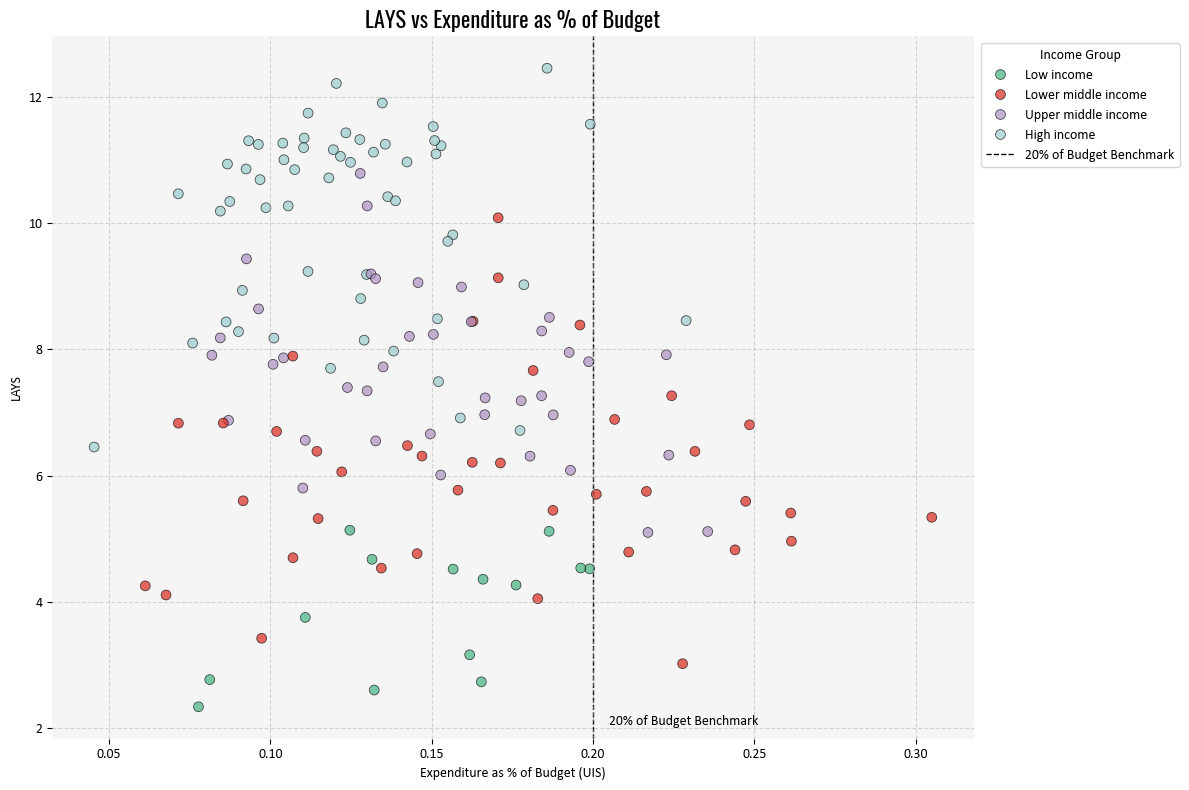

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(data=df, x="expenditure_pctbudget_uis", y="lays",
                hue="income_group",
                palette={"Low income": sc_colors['green'], 
                         "Lower middle income": sc_colors['red'], 
                         "Upper middle income": sc_colors['purple'], 
                         "High income": sc_colors['blue']},
                edgecolor='black', 
                alpha=0.7, 
                s=50, 
                ax=ax)

ax.axvline(x=.2, color='black', linestyle='--', lw=1, label="20% of Budget Benchmark", zorder=0)
ax.text(0.205, 2, "20% of Budget Benchmark", verticalalignment='bottom', fontsize=10)

ax.set_title("LAYS vs Expenditure as % of Budget", fontsize=16, fontname='Oswald')
ax.set_xlabel("Expenditure as % of Budget (UIS)")
ax.set_ylabel("LAYS")
ax.legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('whitesmoke')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)


plt.savefig(FIG_DIR / "lays_vs_expenditure_pctbudget.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

In [ ]:
sns.scatterplot(data=df, x="expenditure_pctgdp", y="lays",
                hue="income_group",
                palette={"Low income": sc_colors['green'], 
                         "Lower middle income": sc_colors['red'], 
                         "Upper middle income": sc_colors['purple'], 
                         "High income": sc_colors['blue']},
                edgecolor='black', 
                alpha=0.7,
                s=50,
                ax=ax[1])

ax[1].axvline(x=.06, color='black', linestyle='--', lw=1, label="6% of GDP Benchmark", zorder=0)
ax[1].text(0.062, 2, "6% of GDP Benchmark", verticalalignment='bottom', fontsize=10)

ax[1].set_title("LAYS vs Expenditure as % of GDP", fontsize=16, fontname='Oswald')
ax[1].set_xlabel("Expenditure as % of GDP")
ax[1].set_ylabel("LAYS")
ax[1].legend(title="Income Group", loc='upper left', bbox_to_anchor=(1, 1)).set_visible(True)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_facecolor('whitesmoke')
ax[1].spines[['top', 'right']].set_visible(False)

In [28]:
#=============================================================================
# Estimate linear models for LAYS vs Expenditure as % of Budget and % of GDP
#=============================================================================

df6 = df.copy()
df6 = df6.dropna(subset=["expenditure_pctbudget_uis", "expenditure_pctgdp"])

df6['log_gdppc'] = np.log(df6['gdppc_2015_usd'])
df6['log_gdppc_s'] = (df6["log_gdppc"] - df6["log_gdppc"].mean()) / df6["log_gdppc"].std()
df6['pct_budget_s'] = (df6["expenditure_pctbudget_uis"] - df6["expenditure_pctbudget_uis"].mean()) / df6["expenditure_pctbudget_uis"].std()
df6['pct_gdp_s'] = (df6["expenditure_pctgdp"] - df6["expenditure_pctgdp"].mean()) / df6["expenditure_pctgdp"].std()

y = df6["lays"]

X = df6[["log_gdppc_s", "pct_budget_s"]]
X = sm.add_constant(X)
model6a = sm.OLS(y, X).fit()


#=============================================================================
# Add interactions with dummies for income groups to test whether the relationship between expenditure as % of GDP and LAYS varies by income group
#=============================================================================

ig_dummies = pd.get_dummies(df6["income_group"], prefix="inc", drop_first=True)
df6 = pd.concat([df6, ig_dummies], axis=1)

interaction_terms = []
for col in ig_dummies.columns:
    interaction_term = df6["pct_budget_s"] * df6[col]
    df6[f"pct_budget_s_{col}"] = interaction_term
    interaction_terms.append(f"pct_budget_s_{col}")


y = df6["lays"]

X = df6[["log_gdppc_s", "pct_budget_s"] + interaction_terms]
X = sm.add_constant(X)
model6b = sm.OLS(y, X).fit()


print("\n\nModel 6a - LAYS vs Expenditure as % of Budget Summary:")
print(model6a.summary())
print("\n\nModel 6b - LAYS vs Expenditure as % of budget, with income group interactions:")
print(model6b.summary())




Model 6a - LAYS vs Expenditure as % of Budget Summary:
                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     150.5
Date:                Fri, 22 May 2026   Prob (F-statistic):           6.62e-36
Time:                        10:46:20   Log-Likelihood:                -257.92
No. Observations:                 146   AIC:                             521.8
Df Residuals:                     143   BIC:                             530.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [29]:
df_lic = df6[df6['income_group'] == 'Low income']

coefs = []

for i in range(len(df_lic)):
    sub = df_lic.drop(df_lic.index[i])
    res = sm.OLS(sub["lays"], sm.add_constant(sub["pct_budget_s"])).fit()
    coefs.append(res.params["pct_budget_s"])

min(coefs), max(coefs)


(np.float64(0.5108055291346917), np.float64(0.7546402066310549))

Light Robustness test. Repeatedly running my regression for LICs, leaving one country out each time to see if my small sample is being skewed by outliers. The difference between the smallest and largest coefficients is small, implying that this is not the case. Given that this is not high stakes analysis, this gives me enough confidence to report on the data. 


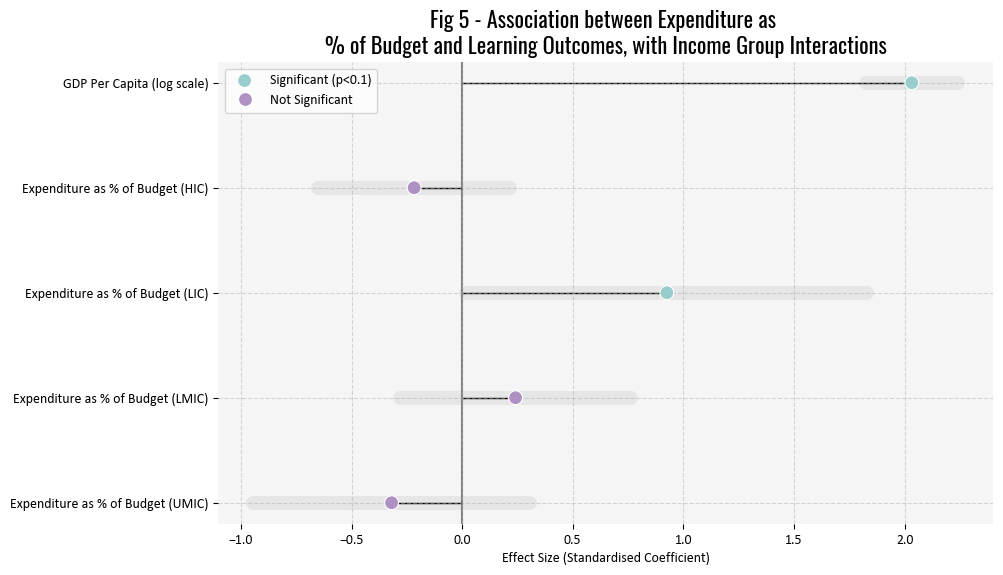

In [30]:
#=============================================================================
# Visualise interaction effects for expenditure as % of budget by income group
#=============================================================================

model = model6b
variables = ["GDP Per Capita (log scale)", 
             "Expenditure as % of Budget (HIC)", 
             "Expenditure as % of Budget (LIC)", 
             "Expenditure as % of Budget (LMIC)", 
             "Expenditure as % of Budget (UMIC)"]

title = "Fig 5 - Association between Expenditure as \n% of Budget and Learning Outcomes, with Income Group Interactions"


model_df = pd.DataFrame({
    "Variable": variables,
    "Coefficient": model.params[1:].values,
    "CI Lower": model.conf_int(alpha=.1).iloc[1:, 0].values,
    "CI Upper": model.conf_int(alpha=.1).iloc[1:, 1].values,
    "Significant": model.pvalues[1:].values < 0.1
})

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('white')

sns.scatterplot(x=model_df["Coefficient"], y=model_df["Variable"], hue=model_df["Significant"], palette={True: sc_colors['blue'], False: sc_colors['purple']}, s=100, ax=ax, zorder=2)

ax.axvline(x=0, color='grey', linestyle='-', zorder=1)

ax.set_facecolor('whitesmoke')
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax.hlines(model_df['Variable'], 0, model_df['Coefficient'], color="black", linestyles="-", linewidth=1, zorder=1)

ax.hlines(y=model_df['Variable'],
    xmin=model_df['CI Lower'],
    xmax=model_df['CI Upper'],
    linewidth=10,
    capstyle="round",
    color=sc_colors['grey'],
    zorder=0
)

plt.xlabel("Effect Size (Standardised Coefficient)")
plt.title(title, fontname='Oswald', fontsize=16)
plt.legend(loc='upper left', labels=['Significant (p<0.1)', 'Not Significant'])
ax.spines[['right','top', 'left', 'bottom']].set_visible(False)
ax.set_ylabel('')
plt.show()

FIG 5 - Association between Expenditure as % of Budget and Learning Outcomes, with Income Group Interactions

This figure shows the standardised coefficients for the interactions between income group of countries and the proportion of their budget allocated to education. While only GDP per capita has a statistically significant association, what is notable is that the proportion of budget allocated to education has a bigger impact on LAYS for Low and Lower Middle Income Countries than for Upper Middle and High Income Countries. The association for LICs would be statistically significant at p<.1. This low significance may also be low due to the small sample size of low income countries in our cohort, and so this should still be considered an important finding. 

# Change in LAYS and Budget over Time

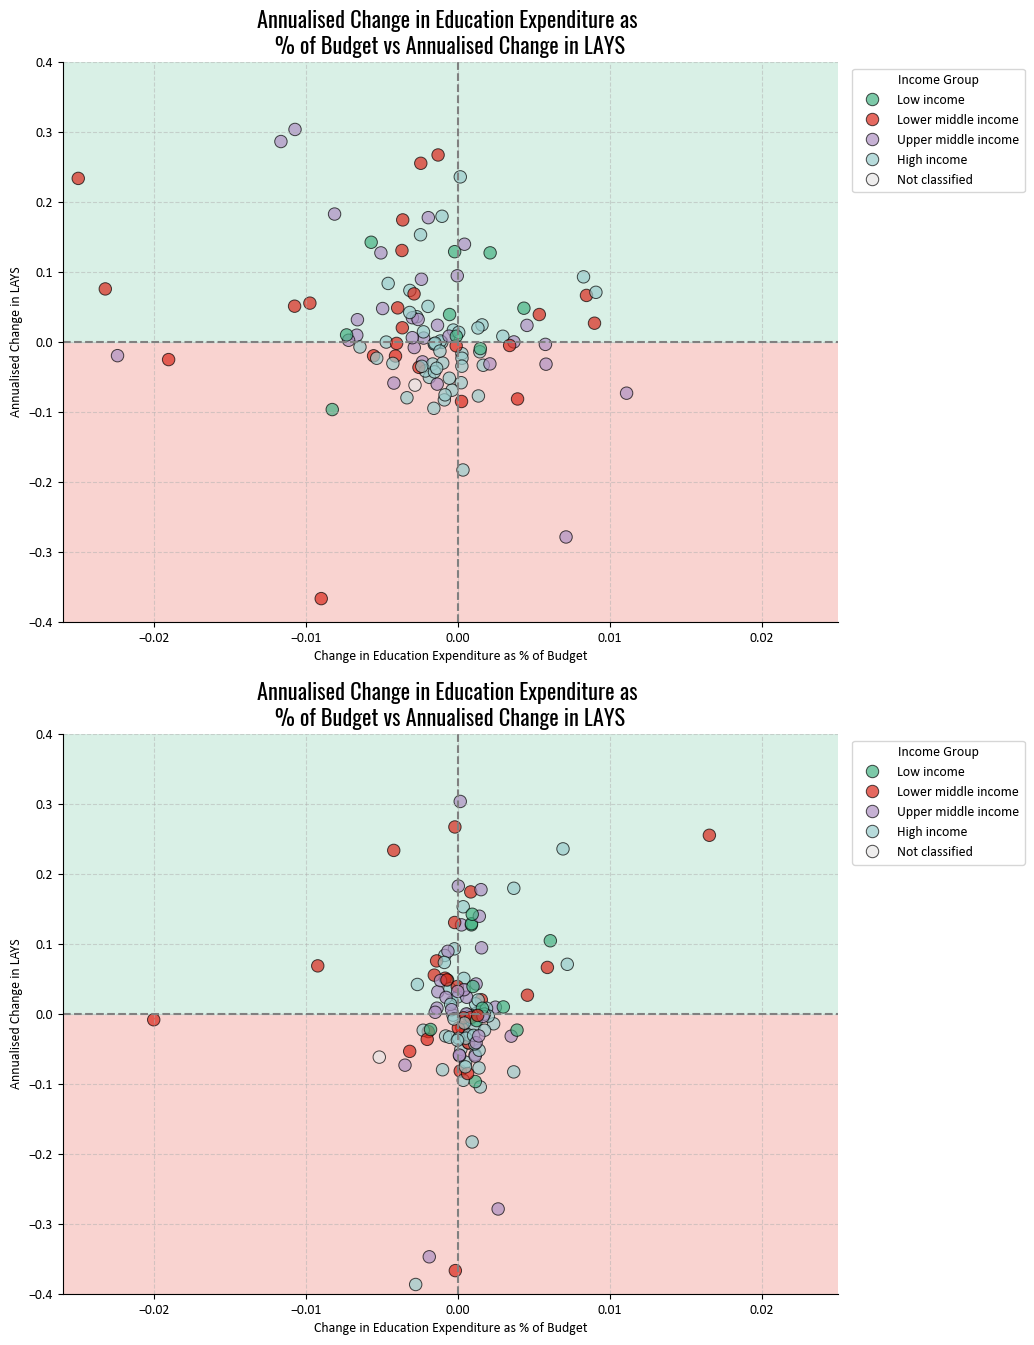

In [168]:

#=====================================================================
# Prepare panel dataset for plotting change in education expenditure vs change in LAYS
#=====================================================================

df = lays_panels.copy()
df = lays_panels[lays_panels['panel'].isin([1, 2, 3, 4, 5])]

agg_map = {col: 'mean' for col in df.columns if col not in ['iso3', 'income_group']}
agg_map['income_group'] = 'first'
df = df.groupby('iso3', as_index=False).agg(agg_map)
# df = df[df['income_group'].isin(['Low income, Low middle income', 'Upper middle income', 'High income'])]

#=============================================================================================
# Plot change in education budget share against change in LAYS
#=============================================================================================


fig, ax = plt.subplots(2, 1, figsize=(10, 16))

ax[0].add_patch(Rectangle(( -0.03, -0.4), 0.06, 0.4, fill=True, color=sc_colors['light red'], alpha=1))
ax[0].add_patch(Rectangle((-0.03, 0), 0.06, 0.4, fill=True, color=sc_colors['light green'], alpha=1))


ax[0].axhline(0, color='grey', linestyle='--')
ax[0].axvline(0, color='grey', linestyle='--')

sns.scatterplot(data=df, x='delta_expenditure_pctbudget_uis', 
                y='delta_lays',
                hue='income_group', 
                # style='panel',
                palette={"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue'],
                            'Not classified': sc_colors['grey']},
                s=80,
                edgecolor='black',
                alpha=0.7,
                ax=ax[0]) 


ax[0].set_xlim(-0.026, 0.025)
ax[0].set_xlabel("Change in Education Expenditure as % of Budget")
ax[0].set_ylabel("Annualised Change in LAYS")
ax[0].set_title("Annualised Change in Education Expenditure as \n% of Budget vs Annualised Change in LAYS", fontsize=16, fontname='Oswald')
ax[0].set_ylim(-.4, .4)

ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_facecolor('whitesmoke')
ax[0].spines[['top', 'right']].set_visible(False)

ax[0].legend(title='Income Group', bbox_to_anchor=(1.01, 1), loc='upper left')

#=============================================================================
# Plot change in share of GDP spent on education against change in LAYS
#=============================================================================



ax[1].add_patch(Rectangle(( -0.03, -0.4), 0.06, 0.4, fill=True, color=sc_colors['light red'], alpha=1))
ax[1].add_patch(Rectangle((-0.03, 0), 0.06, 0.4, fill=True, color=sc_colors['light green'], alpha=1))


ax[1].axhline(0, color='grey', linestyle='--')
ax[1].axvline(0, color='grey', linestyle='--')

sns.scatterplot(data=df, x='delta_expenditure_pctgdp', 
                y='delta_lays',
                hue='income_group', 
                # style='panel',
                palette={"Low income": sc_colors['green'], 
                           "Lower middle income": sc_colors['red'], 
                           "Upper middle income": sc_colors['purple'], 
                           "High income": sc_colors['blue'],
                            'Not classified': sc_colors['grey']},
                s=80,
                edgecolor='black',
                alpha=0.7,
                ax=ax[1]) 


ax[1].set_xlim(-0.026, 0.025)
ax[1].set_xlabel("Change in Education Expenditure as % of Budget")
ax[1].set_ylabel("Annualised Change in LAYS")
ax[1].set_title("Annualised Change in Education Expenditure as \n% of Budget vs Annualised Change in LAYS", fontsize=16, fontname='Oswald')
ax[1].set_ylim(-.4, .4)

ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_facecolor('whitesmoke')
ax[1].spines[['top', 'right']].set_visible(False)

ax[1].legend(title='Income Group', bbox_to_anchor=(1.01, 1), loc='upper left')


fig.savefig(FIG_DIR / "delta_expenditure_vs_delta_lays.png", dpi=300, bbox_inches="tight")

# **Exports**

Important communication outputs are exported in the same cells where they are produced.
Figures are saved to `Results/figures/` via `FIG_DIR`; summary tables are saved to `Results/tables/` via `TAB_DIR`.